In [ ]:
import sys
from pathlib import Path

# Add the workspace root to path to enable proper imports
workspace_root = Path.cwd()
sys.path.insert(0, str(workspace_root))

from src.graph_generator import generate_graph, display_graph, display_path
from src.algorithms.ant_system import resolve_by_ant_system
from src.algorithms.tabu_search import resolve_by_tabu_search
from src.algorithms.tabu_search_2opt import resolve_by_tabu_search_with_2opt
from src.algorithms.hill_climbing_ms import resolve_by_ms_hill_climbing
from src.algorithms.nearest_neighbor import resolve_by_nearest_neighbor
from src.algorithms.genetic import resolve_by_genetic

graph = generate_graph(10)
display_graph(graph)

ImportError: attempted relative import beyond top-level package

In [ ]:
# Multi-start hill climbing
ms_hill_climbing_tour, ms_hill_climbing_cost = resolve_by_ms_hill_climbing(graph, iterations=100)
print('Best tour:', ms_hill_climbing_tour)
print('Total cost:', ms_hill_climbing_cost)
display_path(graph, ms_hill_climbing_tour)

NameError: name 'resolve_by_ms_hill_climbing' is not defined

Best tour: [4, 8, 3, 7, 5, 1, 9, 2, 6, 0, 4]
Total cost: 43.65


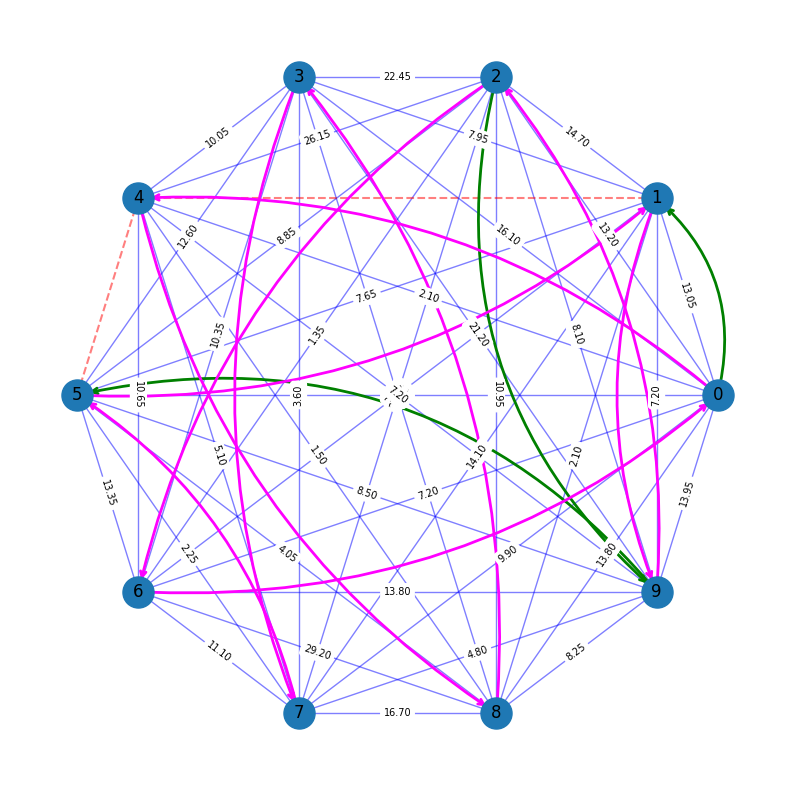

In [ ]:
# Ant System
ant_system_tour, ant_system_cost = resolve_by_ant_system(graph, n_iterations=100, n_ants=100)
print('Best tour:', ant_system_tour)
print('Total cost:', ant_system_cost)
display_path(graph, ant_system_tour)

Best tour: [5, 7, 3, 8, 1, 9, 4, 0, 6, 2, 5]
Total cost: 44.55


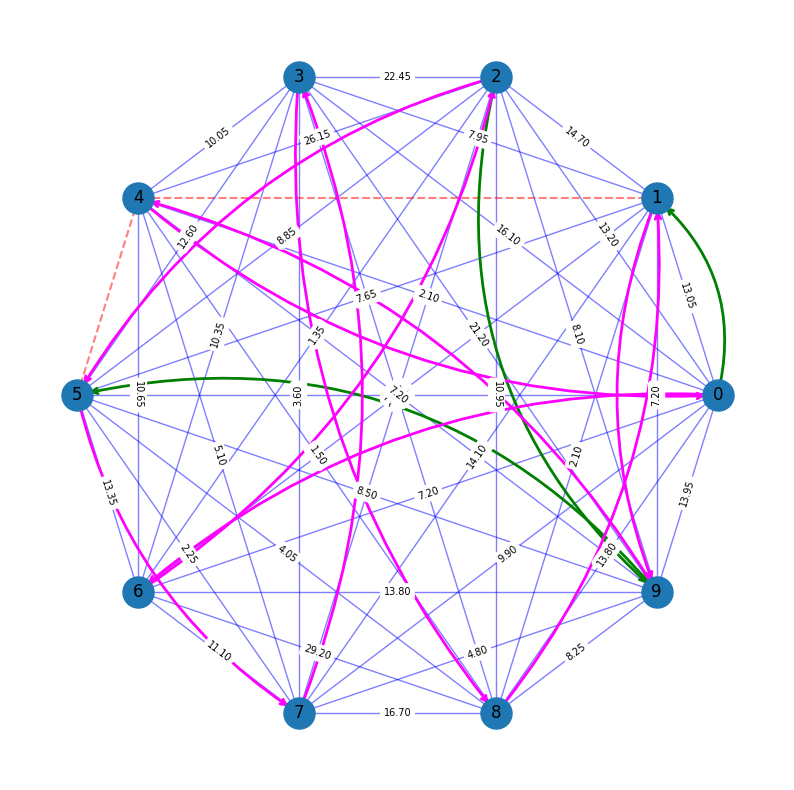

In [ ]:
# Tabu Search
tabu_tour, tabu_cost = resolve_by_tabu_search(graph, n_iterations=500)
print(f"Best tour: {tabu_tour}")
print(f"Total cost: {tabu_cost}")
display_path(graph, tabu_tour)

Best tour: [5, 1, 9, 2, 6, 0, 4, 8, 3, 7, 5]
Total cost: 43.65


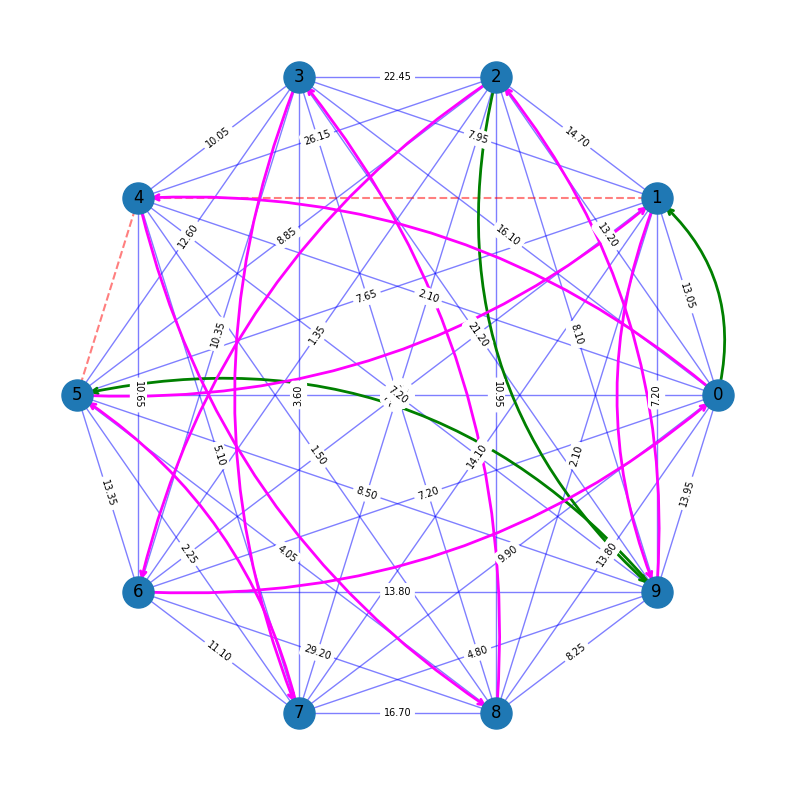

In [ ]:
# Tabu Search with 2-opt
tabu_2opt_tour, tabu_2opt_cost = resolve_by_tabu_search_with_2opt(graph, n_iterations=500)
print(f"Best tour: {tabu_2opt_tour}")
print(f"Total cost: {tabu_2opt_cost}")
display_path(graph, tabu_2opt_tour)

Best tour: [5, 7, 3, 8, 4, 9, 1, 0, 6, 2, 5]
Total cost: 54.900000000000006


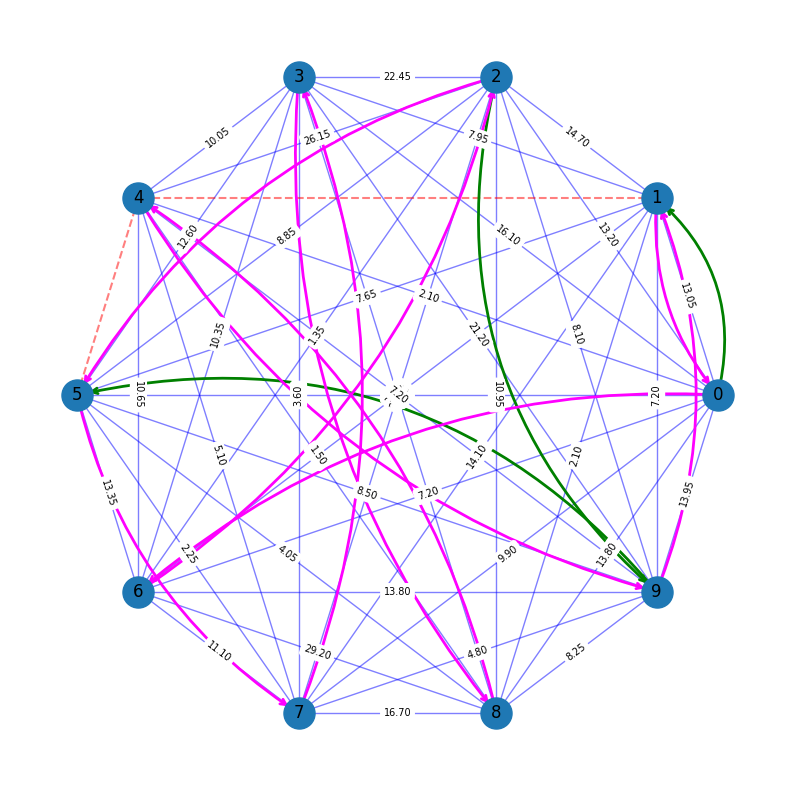

In [ ]:
# Nearest Neighbor
nn_tour, nn_cost = resolve_by_nearest_neighbor(graph)
print('Best tour:', nn_tour)
print('Total cost:', nn_cost)
display_path(graph, nn_tour)

Best tour: [7, 5, 1, 9, 4, 0, 6, 2, 8, 3, 7]
Total cost: 52.199999999999996


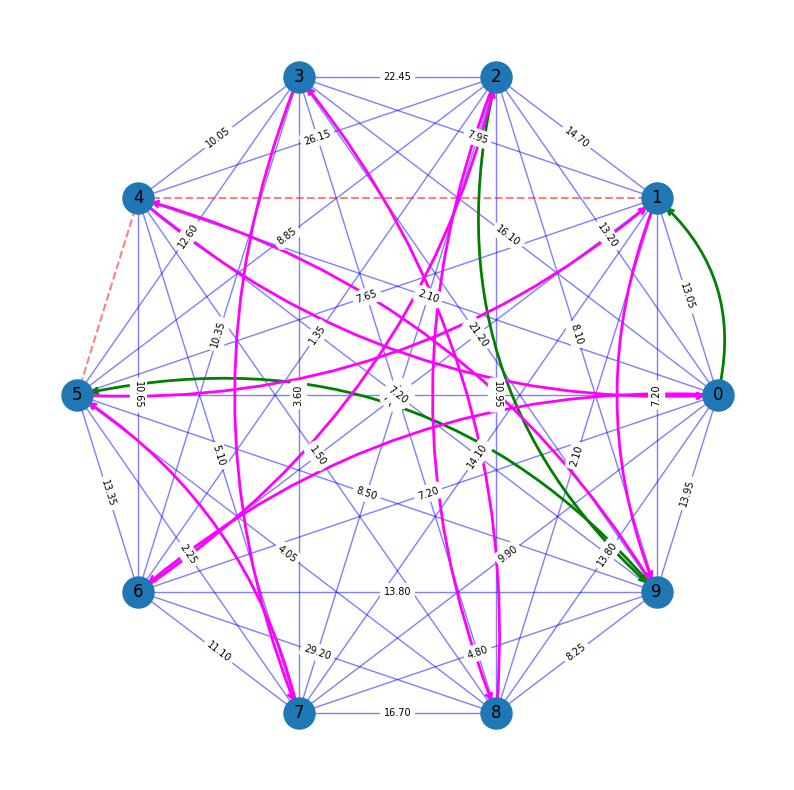

In [ ]:
# Genetic Algorithm
genetic_tour, genetic_cost = resolve_by_genetic(graph)
print('Best tour:', genetic_tour)
print('Total cost:', genetic_cost)
display_path(graph, genetic_tour)

Best tour: [5, 7, 3, 8, 1, 9, 4, 0, 6, 2, 5]
Total cost: 44.55


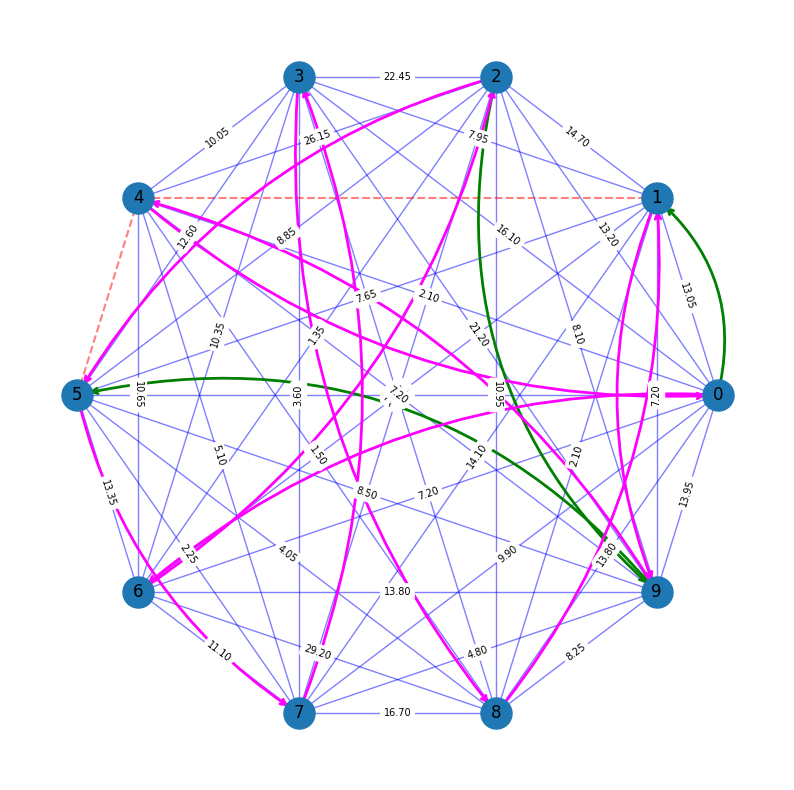

In [ ]:
# Tabu Search
tour, cost = resolve_by_tabu_search(graph, n_iterations=500)
print(f"Best tour: {tour}")
print(f"Total cost: {cost}")
display_path(graph, tour)

Best tour: [2, 19, 10, 1, 17, 8, 9, 11, 14, 3, 13, 0, 7, 6, 5, 16, 12, 15, 18, 4, 2]
Total cost: 56.99999999999999


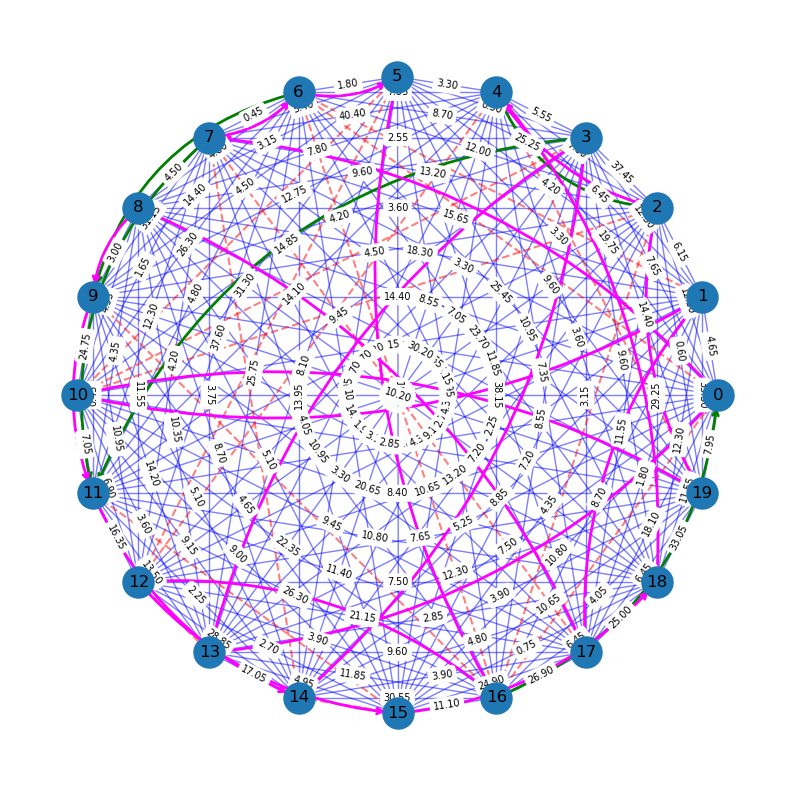

In [ ]:
# Tabu Search with 2-opt
tour, cost = resolve_by_tabu_search(graph, n_iterations=500)
print(f"Best tour: {tour}")
print(f"Total cost: {cost}")
display_path(graph, tour)

In [ ]:
# Recuit Simulé
from src.algorithms.recuit_simule import resolve_by_recuit_simule

recuit_tour, recuit_cost = resolve_by_recuit_simule(graph, max_iterations=10000, seed=0)
print('Best tour:', recuit_tour)
print('Total cost:', recuit_cost)
display_path(graph, recuit_tour)


In [ ]:
# Recuit Simulé Multi-Start
from src.algorithms.recuit_simule import resolve_by_ms_recuit_simule

ms_recuit_tour, ms_recuit_cost = resolve_by_ms_recuit_simule(
    graph,
    n_restarts=100,
    max_iterations_per_restart=2000,
    max_time_seconds=15.0,  # budget global pour toutes les relances
    alpha=0.995,
    seed=0
)
print('Best tour:', ms_recuit_tour)
print('Total cost:', ms_recuit_cost)
display_path(graph, ms_recuit_tour)


# Recherche opérationnelle: résolution d'un problème de tournée de véhicules
Membres du groupe: Timothé FARDELLA, Léo MARTIN, Antoine POUZOULET, Louis LE ROUX, Clément OMNÈS

## 1.0. Introduction

L'ADEME confie à notre structure CesiCDP l'étude et le développement de nouvelles solutions de mobilité multimodale intelligente afin de répondre aux enjeux actuels de réduction des émissions de gaz à effet de serre. Le projet vise à modéliser et optimiser des tournées de livraison sur un réseau routier, tout en minimisant la durée totale des trajets et en assurant une gestion optimisée des ressources. Pour ce faire, dans ce livrable nous établirons la modélisation formelle du problème ainsi que son analyse de complexité. Pour la bonne compréhension des principes mathématiques et de nos modélisations, nous avons choisi de réaliser un contexte qui sera utilisé comme exemple tout au long de ce document. 


### 1.1. Contexte
Le contexte choisi est une boucherie confrontée à un défi logistique lors des fêtes de fin d'année. En effet, pour noël la boucherie à subit un grand nombre de commande à livrer en peu de temps et demande alors à son prestataire de livraison (l’ADEME) de trouver une solution pour livrer les commandes efficacement.

Les villes à livrer sont :
- Paris (Point de départ et d'arrivée - Dépôt)
- Rennes
- Rouen
- Bordeaux
- Toulouse
- Lyon

### 1.2. Objectifs d'optimisation

L'objectif est de minimiser le coût total d'une tournée de livraison, c'est-à-dire trouver le chemin le plus court et le moins coûteux permettant à un véhicule de visiter un ensesmble de villes et de revenir à son point de départ. En réduisant les distances parcourues et en évitant les routes les plus coûteuses, on limite directement la consommation de carburant, les émissions polluantes et le temps de trajet. Dans ce contexte, le gain de temps permettra de livrer les commandes à temps pour le repas de noël et à long terme de diminuer les coûts et les émissions CO2 de livraison.

---

## 2.0. Représentation mathématique

### 2.1. Définition des variables

Soit:
- $G= \{V;E\}$ un graphe comportant un ensemble de sommets et d'arêtes.
- $V= \{v_0, v_1, ..., v_{n-1}\}$ un ensemble de sommets.
- $E= \{ \{u,v\}\ \mid u;v \in V, u \neq v\}$ un ensemble contenant des arêtes non orientées, où chaque élément est une paire de sommets distincts $u$ et $v$ appartenant à $V$.
- $P(u,v) = P_{péage} + (e \times P_{distance})$ le poids associé à l'arête entre $u$ et $v$ et $e$ le prix de l'essence par kilomètre.
- $D$ un ensemble de contraintes de précédances sachant que D ⊆ V×V.
- $x_{u,v} \in \{0, 1\}$ est une variable de décision valant $1$ si l'arête $(u,v)$ est empruntée dans la tournée, $0$ sinon.
- $\forall (u,v) \in D, t_u < t_v$ avec $t_u$ le rang de passage du sommet $u$ et $t_v$ le rang de passage du sommet $v$.

</br>

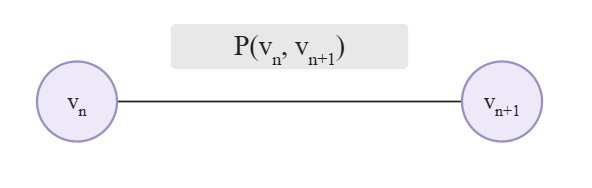

**Ce graphe illustre la modélisation de notre réseau de transport pour le projet CesiCDP. La structure de ce Problème est celle du Voyageur de Commerce (TSP).**

- **Les sommets** : Chaque nœud du graphe correspond à l'une des six villes clés du réseau de distribution. Par exemple, le sommet $v_n$ peut représenter le centre de distribution principal à Paris (point de départ de nos produits), et le sommet $v_{n+1}$ peut désigner Rouen ou Rennes, la prochaine étape où le prestataire logistique doit livrer une commande. 
- **L'arête unique** : Le trait qui relie les deux sommets modélise le réseau routier existant (autoroutes, routes nationales) qu'emprunte le véhicule de l'ADEME pour se rendre de la ville $v_n$ à la ville $v_{n+1}$. Dans notre TSP, le graphe est complet, ce qui signifie qu'il existe une arête entre chaque paire de villes.
- **Le poids ($P(v_n, v_{n+1})$)** : Cette étiquette représente le critère d'optimisation central de notre problème. Elle quantifie l'effort nécessaire pour parcourir cette arête. Dans ce contexte précis, ce poids traduit la distance totale ou le temps de trajet entre deux villes, des facteurs directement corrélés à la consommation énergétique et à l'empreinte carbone.
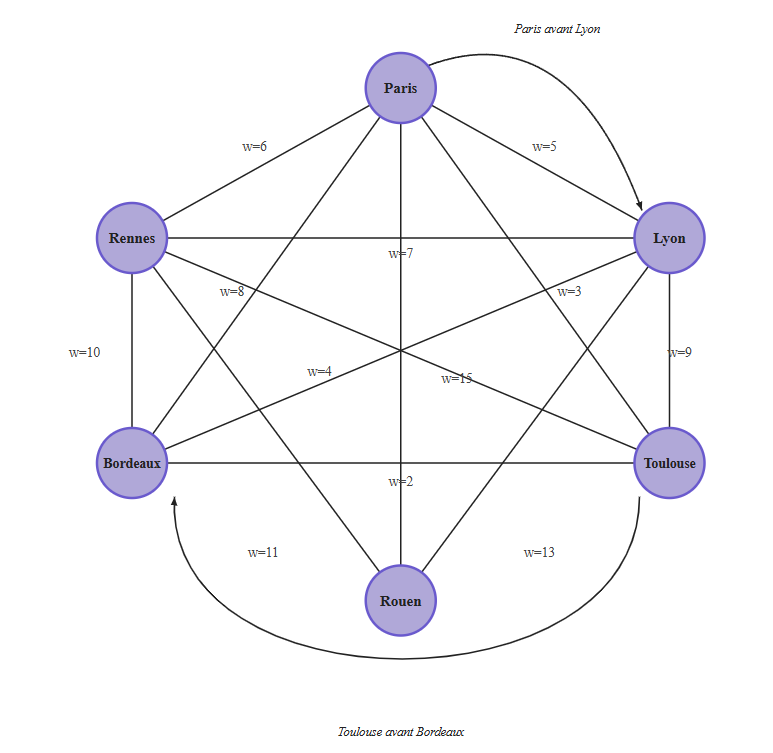
- Le graphe représente une instance du problème TSP-PC-ER appliqué à un réseau de livraison pour une boucherie. Il s'agit d'un graphe complet comportant 6 sommets (villes) et 15 arêtes pondérées.
- **Les sommets représentent les villes à livrer :** $V=\{Rennes,Rouen,Bordeaux,Toulouse,Paris,Lyon\}$
- Les arêtes sont pondérées par la fonction de $\text{coût péage} + \text{le prix de l'essence} \times \text{la distance entre deux villes}$
- Les valeurs $−1$ matérialisent les routes interdites au sens de la contrainte *3.2.1* : ces liaisons ne peuvent pas être empruntées lors de la tournée. Dans notre contexte cela symboliserai une route en travaux qui ne pourra donc pas être empruntée. 
- Les arêtes valides portent des poids entiers positifs représentant le coût de chaque trajet.

---

## 3.0. Définition des fonctions

Dans cette section, nous traduisons le besoin opérationnel de la boucherie en fonctions mathématiques. La démarche suivie est la suivante : identifier la décision logistique à prendre (choisir ou non une arête), associer un coût réel à chaque liaison, puis formaliser les contraintes du terrain (routes interdites et ordre de passage).

Ainsi, les fonctions définies ci-dessous ne sont pas abstraites : elles correspondent directement au contexte de livraison avant Noël, où l'on cherche à minimiser les coûts tout en respectant les contraintes de circulation et d'organisation.

### 3.1. Définition de la fonction objectif

$$\text{min Z} = \sum_{u=0}^{n} \sum_{v=0}^{n} P(u,v) ⋅ x_{(u,v)}$$

L'objectif du problème est de minimiser le coût total du trajet. Le coût d'un trajet dépend de deux éléments déjà définis dans la section 1.0 :

- La variable binaire $x_{u,v} \in \{0,1\}$, qui indique si l'arête entre $u$ et $v$ est utilisée dans la tournée ($1$ = empruntée, $0$ = ignorée).
- Le poids $P(u,v)=P_{péage} + (e \times P_{distance})$, qui représente le coût réel de chaque route, en intégrant les péages et la consommation de carburant.

La somme double sur tous les couples $(u,v)$ agrège le coût total de la tournée, en ne comptant que les arêtes sélectionnées. Les arêtes non retenues (où $x_{u,v}=0$) ne contribuent pas à la somme.

Dans le contexte appliqué, cette fonction objectif correspond à la recherche de la tournée la moins coûteuse pour livrer toutes les villes puis revenir au dépôt (Paris). En minimisant cette quantité, on réduit à la fois les dépenses logistiques, la consommation de carburant et l'impact environnemental.

</br>

### 3.2. Définition des fonctions contraintes

Les contraintes permettent d'intégrer les réalités du problème dans le modèle. Elles évitent de produire une solution mathématiquement optimale mais logistiquement irréaliste.

#### 3.2.1. Contrainte de coût et d'arêtes interdites

Une arête $(u,v)$ est considérée comme interdite lorsque son poids vaut $-1$. On impose alors :

$$x_{u,v} = 0 \ \forall(u,v) \in \text{tel que } P(u,v) = -1$$

Cette contrainte traduit le fait qu'une liaison bloquée (ou non autorisée) ne peut jamais être empruntée pendant la tournée.

#### 3.2.2. Contrainte de précédances

Pour toute paire $(u,v) \in D$, la ville $u$ doit être visitée avant la ville $v$:

$$t_u < t_v ∀(u,v) \in D$$

Cette contrainte modélise un ordre de livraison imposé (priorité de certains clients, organisation de tournée, contraintes métier). Elle garantit que la solution retenue reste cohérente avec les exigences opérationnelles du contexte.


## 4.0. Calcul de complexité

### 4.1. Identification du problème

Notre problème est une extension du **problème du Voyageur de Commerce** (TSP — *Travelling Salesman Problem*), noté **TSP-PC-ER**, car il intègre deux contraintes supplémentaires par rapport au TSP classique :

- **PC** (*Precedence Constraints*) — l'ensemble $D \subseteq V \times V$ impose un ordre de visite entre certaines villes : $\forall (u,v) \in D,\ t_u < t_v$
- **ER** (*Edge Restrictions*) — certaines arêtes sont bloquées ($P_n(u,v) = -1$) ou affectées d'un surcoût

La méthode utilisée pour déterminer la complexité d'un problème est la **réduction polynomiale** : on montre qu'un problème déjà connu comme difficile se ramène au nôtre. On s'appuie sur la chaîne suivante :

$$\underbrace{\text{Ham-Cycle}}_{\text{NP-Complet}} \leq_p \underbrace{\text{TSP}}_{\text{NP-Difficile (Karp, 1972)}} \leq_p \underbrace{\text{TSP-PC-ER}}_{\text{notre problème}}$$

La réduction Ham-Cycle $\leq_p$ TSP est un résultat établi de la littérature (Karp, 1972), cité ici comme acquis. Nous démontrons la seconde réduction : **TSP $\leq_p$ TSP-PC-ER**.

### 4.2. TSP-PC-ER $\in$ NP

Un certificat est une liste ordonnée des sommets du circuit. On vérifie en $O(n)$ que :

- chaque sommet apparaît exactement une fois,
- aucune arête empruntée n'est bloquée ($P(u,v) \neq -1$),
- la somme des poids des arêtes consécutives est au plus $k$,
- toutes les contraintes de précédence de $D$ sont respectées.

La vérification est polynomiale, donc :

$$\text{TSP-PC-ER} \in NP$$

### 4.3. Réduction TSP $\leq_p$ TSP-PC-ER


Le TSP classique est un **cas particulier** de notre problème TSP-PC-ER.  
La réduction se construit ainsi : étant donné une instance TSP quelconque — un graphe $G = (V, E, w)$ — on construit une instance TSP-PC-ER en posant :

$$D = \emptyset \qquad \text{et} \qquad P(u,v) = w(\{u,v\}) \quad \forall \{u,v\} \in E$$

- $D = \emptyset$ signifie qu'on ne définit **aucune contrainte de précédence**
- $P(u,v) = w(\{u,v\})$ signifie qu'on recopie les poids tels quels, **sans route bloquée ni surcoût**

Cette transformation ne modifie rien — elle recopie l'instance en $O(1)$, ce qui est triviallement polynomial.

On obtient alors exactement l'instance TSP de départ. On en déduit :

$$\text{TSP} \leq_p \text{TSP-PC-ER}$$

Si on savait résoudre TSP-PC-ER efficacement, on saurait aussi résoudre TSP — ce qui est impossible puisque TSP est NP-Difficile. Les schémas ci-dessous illustrent cette réduction : à gauche le TSP pur (tous les poids à 1, aucune contrainte), à droite le TSP-PC-ER avec ses contraintes. En posant $D = \emptyset$ et $P(u,v) = 1$ partout, on passe du second au premier.

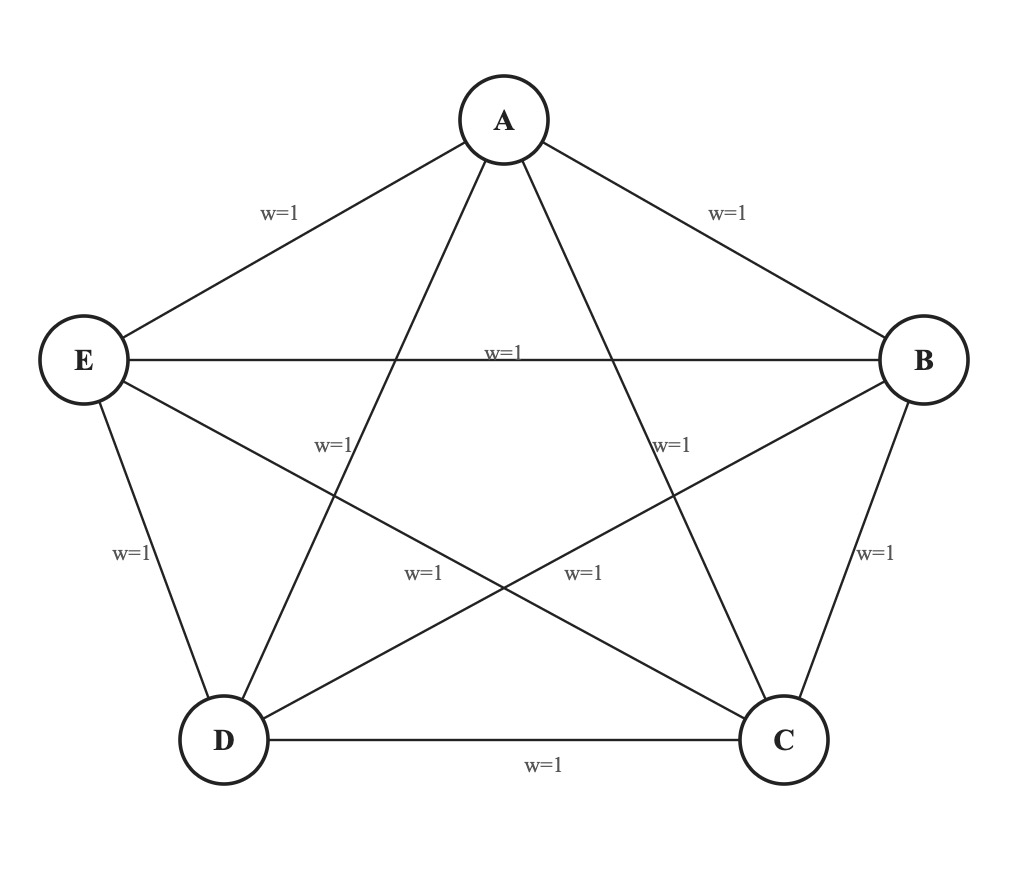
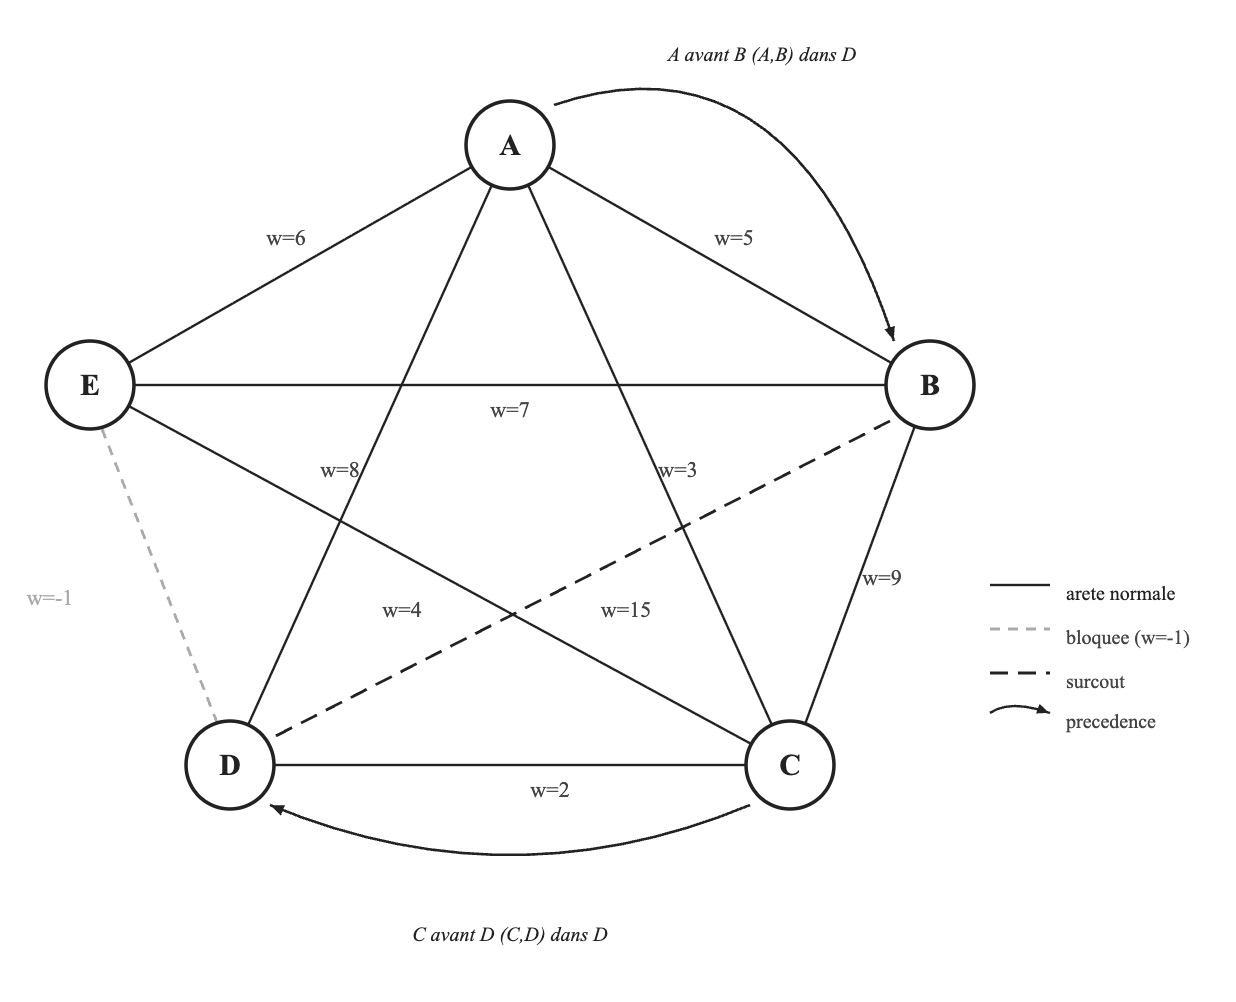

### 4.4. Les contraintes ne simplifient pas le problème

On pourrait penser que l'ajout de contraintes réduit la difficulté du problème — en interdisant des arêtes ou en imposant un ordre de visite, on élimine des tournées invalides. C'est vrai en pratique, mais insuffisant pour changer la classe de complexité.

Sans aucune contrainte, le nombre de tournées distinctes à explorer pour $n$ sommets est :

$$\frac{(n-1)!}{2}$$

Ce résultat s'explique en deux étapes : on fixe $v_0$ comme point de départ, ce qui ramène le nombre de permutations à $(n-1)!$, puis on divise par $2$ car parcourir un cycle dans un sens ou dans l'autre revient au même sur un graphe non orienté.

Nos contraintes réduisent ce nombre, mais il reste **exponentiel en $n$** — diviser par une constante ne change pas l'ordre de grandeur asymptotique.

| $n$ (sommets) | $(n-1)!/2$ | Ordre de grandeur |
|:---:|---:|:---:|
| 5 | 12 | $10^1$ |
| 10 | 181 440 | $10^5$ |
| 15 | 43 589 145 600 | $10^{10}$ |
| 20 | 60 822 550 204 416 000 | $10^{16}$ |

Il n'existe donc pas d'algorithme polynomial connu permettant de résoudre TSP-PC-ER de manière exacte pour de grandes instances. Cela justifie le recours à des **heuristiques** dans les phases suivantes du projet.

---

## 5.0. Conclusion

Ce livrable avait pour objectif de poser les fondements formels du problème de tournée de livraison confié par l'ADEME à CesiCDP. À travers les différentes sections, nous avons progressivement construit un cadre rigoureux, du contexte applicatif jusqu'à l'analyse de complexité.

Nous avons d'abord modélisé le problème sous la forme d'un graphe complet $G = (V, E)$, où les sommets représentent les six villes à livrer et les arêtes portent un poids reflétant le coût réel de chaque trajet, péages et consommation de carburant inclus. Deux contraintes ont été intégrées au modèle : l'interdiction de certaines routes ($P(u,v) = -1$) et des contraintes de précédence imposant un ordre de visite entre certaines villes.

Nous avons ensuite montré que ce problème, que nous notons TSP-PC-ER, est une extension du problème du Voyageur de Commerce classique. Par réduction polynomiale depuis le cycle hamiltonien, nous avons établi la chaîne :

$$\text{Ham-Cycle} \leq_p \text{TSP} \leq_p \text{TSP-PC-ER}$$

Ce résultat implique que TSP-PC-ER est NP-Difficile : aucun algorithme polynomial connu ne peut le résoudre de manière exacte pour de grandes instances. Le nombre de tournées à explorer croît de façon factorielle avec le nombre de villes, ce que le tableau de la section *4.4* illustre clairement.

Ces conclusions justifient pleinement le recours à des heuristiques dans les phases suivantes du projet, qui viseront à produire des solutions de bonne qualité en temps raisonnable, sans prétendre à l'optimalité garantie.

---


## 6.0. Références bibliographiques

### 6.1. Livres

- APPLEGATE, David L., BIXBY, Robert E., CHVÁTAL, Václav, COOK, William J. The Traveling Salesman Problem: A Computational Study. Princeton : Princeton University Press, 2006. p.606
  *Utilisé pour justifier le recours aux heuristiques face à la croissance factorielle du nombre de tournées (section 4.4).*

- GAREY, Michael R., JOHNSON, David S. Computers and Intractability: A Guide to the Theory of NP-Completeness. New York : W.H. Freeman, 1979. p.338
  *Utilisé pour appuyer la conclusion de la réduction TSP ≤p TSP-PC-ER et la NP-difficulté du problème (section 4.3).*

- FOURNIER, Jean-Claude. Théorie des graphes et applications : avec exercices et problèmes. 2e éd. revue et augmentée. Paris : Hermès - Lavoisier, 2011.
  *Utilisé pour fonder la modélisation du problème sous forme de graphe complet pondéré $G = (V, E)$ (section 2.0).*

- FAURE, Robert, LEMAIRE, Bernard, PICOULEAU, Christophe. Précis de recherche opérationnelle : Méthodes et exercices d'application. 7e éd. Paris : Dunod, 2014.
  *Utilisé pour la formulation en programmation linéaire en nombres entiers (PLNE), variables binaires $x_{u,v}$ et fonction objectif (section 2.0).*

### 6.2. Chapitres d'ouvrages collectifs

- COOK, Stephen A. The complexity of theorem-proving procedures. In Proceedings of the Third Annual ACM Symposium on Theory of Computing (STOC). New York : ACM, 1971. p. 151-158.
  *Utilisé pour fonder la notion de certificat vérifiable en temps polynomial et justifier que TSP-PC-ER ∈ NP (section 4.2).*

- GENDREAU, Michel, LAPORTE, Gilbert, POTVIN, Jean-Yves. Metaheuristics for the capacitated VRP. In TOTH, Paolo, VIGO, Daniele dir. The Vehicle Routing Problem. Philadelphia : SIAM, 2002. p. 129-154.
  *Utilisé pour justifier le recours aux heuristiques sur les extensions du TSP avec contraintes de précédence et d'arêtes bloquées (section 4.4).*

- KARP, Richard M. Reducibility among combinatorial problems. In MILLER, Raymond E., THATCHER, James W. dir. Complexity of Computer Computations. New York : Plenum Press, 1972. p. 85-103.
  *Utilisé pour établir la chaîne de réduction Ham-Cycle ≤p TSP ≤p TSP-PC-ER et la NP-difficulté du TSP (section 4.1).*

### 6.3. Articles de revues

- DANTZIG, George B., FULKERSON, D. Ray, JOHNSON, Selmer M. Solution of a large-scale traveling-salesman problem. Journal of the Operations Research Society of America, 1954, vol. 2, n° 4, p. 393-410.
  *Utilisé pour la formulation originale de la fonction objectif min Z du TSP sous forme de somme pondérée des arêtes sélectionnées (section 3.1).*